# Animating the colorbar in matplotlib

This has been tricky.

1.0 8.282933578371178
2.0 10.28268184956277
3.0 12.282430120754364
4.0 14.282178391945957
5.0 16.281926663137547
6.0 18.281674934329143
7.0 20.281423205520735
8.0 22.281171476712327
9.0 24.28091974790392


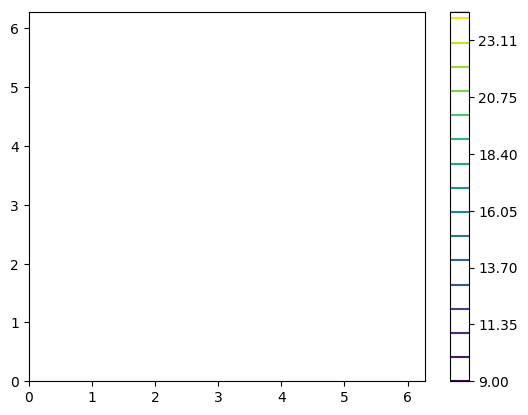

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as mpla

# Create some data
x = np.linspace(0, 2 * np.pi, 100)
y = np.linspace(0, 2 * np.pi, 100)
X, Y = np.meshgrid(x,y)
levels = 15

# Create a figure and axis
fig, ax = plt.subplots()
Z = X + np.sin(Y)**2
sc = ax.contour(X, Y, Z, levels, cmap='viridis')

# Add a colorbar
colorbar = plt.colorbar(sc)
colorbar.boundaries = np.round(np.linspace(np.min(Z), np.max(Z), levels-1),3)
# sc.set_array(Z.flatten())
# colorbar.update_normal(sc)

ims = []
ims.append([sc,])

# Function to update the scatter plot and colorbar
def update(frame):
    # ax.clear()
    Z = X + frame * np.sin(Y)**2 + frame
    sc = ax.contour(X, Y, Z, levels, cmap='viridis', vmin=np.min(Z), vmax=np.max(Z))
    # sc.set_array(Z.flatten())
    print(np.min(Z), np.max(Z))
    colorbar.boundaries = np.round(np.linspace(np.min(Z), np.max(Z), levels-1),3)
    # colorbar.mappable = sc
    colorbar.update_normal(sc)
    # colorbar.set_ticks(np.round(np.linspace(np.min(Z), np.max(Z), levels-1),3))
    ims.append([sc,])
    
nframes = 10
for frame in range(1, nframes):
    update(frame)
# Create animation
# ani = animation.FuncAnimation(fig, update, frames=10, interval=50)
ani = mpla.ArtistAnimation(fig, ims)
# ims[0]
# plt.show()

In [2]:
mpla.ArtistAnimation?

Init signature: mpla.ArtistAnimation(fig, artists, *args, **kwargs)
Docstring:     
`TimedAnimation` subclass that creates an animation by using a fixed
set of `.Artist` objects.

Before creating an instance, all plotting should have taken place
and the relevant artists saved.

.. note::

    You must store the created Animation in a variable that lives as long
    as the animation should run. Otherwise, the Animation object will be
    garbage-collected and the animation stops.

Parameters
----------
fig : `~matplotlib.figure.Figure`
    The figure object used to get needed events, such as draw or resize.
artists : list
    Each list entry is a collection of `.Artist` objects that are made
    visible on the corresponding frame.  Other artists are made invisible.
interval : int, default: 200
    Delay between frames in milliseconds.
repeat_delay : int, default: 0
    The delay in milliseconds between consecutive animation runs, if
    *repeat* is True.
repeat : bool, default: True
   

In [3]:
ani.save('test.mp4', fps=10)


In [31]:
from IPython.display import HTML

HTML("""
<video controls id="theVideo">
        <source src="test.mp4">
</video>

<script>
video = document.getElementById("theVideo")
video.width = 800;
video.playbackRate = .6;
video.loop = true;
</script>
""")


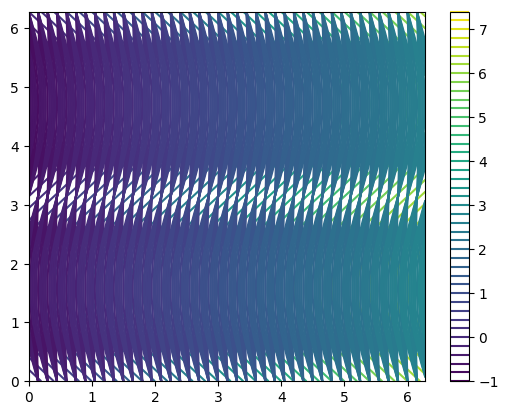

In [34]:
from celluloid import Camera

# Create some data
x = np.linspace(0, 2 * np.pi, 100)
y = np.linspace(0, 2 * np.pi, 100)
X, Y = np.meshgrid(x,y)

# Create a figure and axis
fig, ax = plt.subplots()
camera = Camera(fig)

Z = X + np.sin(Y)
sc = ax.contour(X, Y, Z, levels=50, cmap='viridis')

# Add a colorbar
colorbar = plt.colorbar(sc)
colorbar.boundaries = np.round(np.linspace(np.min(Z), np.max(Z), 10),1)

frames = 10
for fr in range(1, frames):
    # ax.clear()
    Z = X + .03*fr * np.sin(Y)
    sc = ax.contour(X, Y, Z, levels=50, cmap='viridis')
    sc.set_array(Z.flatten())
    colorbar.boundaries = np.round(np.linspace(np.min(Z), np.max(Z), 10),1)
    # colorbar.update_normal(sc)
    camera.snap()
    

In [35]:
animation = camera.animate()
# plt.show()
animation.save('ctest.mp4', fps=20)

In [36]:
from IPython.display import HTML

HTML("""
<video controls id="theVideo2">
        <source src="ctest.mp4">
</video>
z
<script>
video2 = document.getElementById("theVideo2")
video2.width = 800;
video2.playbackRate = .6;
video2.loop = true;
</script>
""")

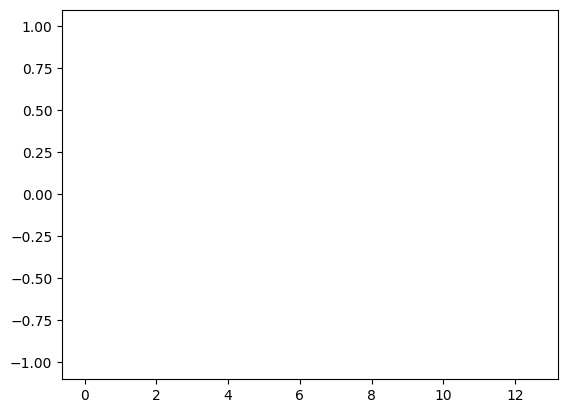

In [37]:
# Create figure and axis
fig, ax = plt.subplots()
frames = []

# Pre-render frames
for i in range(10):
    x = np.linspace(0, 4 * np.pi, 100)
    y = np.sin(x + i * 0.2)
    frame, = ax.plot(x, y, 'b')
    frames.append([frame])

# Create animation
ani = mpla.ArtistAnimation(fig, frames, interval=200, blit=True)

In [38]:
ani.save('tt.mp4')

In [42]:
HTML("""
<div><h1>Hello!</h1></div>
<video controls id="theVideo2">
        <source src="tt.mp4">
</video>
<script>
video2 = document.getElementById("theVideo2")
video2.width = 800;
video2.playbackRate = .6;
video2.loop = true;
</script>
""")